In [1]:
import pandas as pd
from sklearn.metrics import hamming_loss

In [2]:
df = pd.read_csv("/kaggle/input/research-multilabel-text/reviewsDataset.csv")
df.head()

,reviewContent,ground_truth_aspects
0,"আলহামদুলিল্লাহ, প্রোডাক্টটি অনেক ভালো! সাউন্ড ...","product, packaging"
1,"অসাধারণ একটা প্রডাক্ট হাতে পেলাম,সত্যিই অসাধার...","product, seller, packaging"
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller"
3,"যেমন ওর্ডার করেছি তেমন পেয়েছি,প্যাকেটিং ভালো ছ...","product, packaging, seller"
4,১০০% আসল প্রোডাক্ট। সিলেটের মধ্যে ৮ দিনের মধ্য...,"product, delivery, seller"


In [3]:
df.reviewContent[2]

'আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে নিতে পারেন যে রকম কথা ছিল সেই রকম দিসে ধ্যনবাদ দারাজ এবং সেলার '

In [4]:
import re
import string
import unicodedata

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        u"\U00002600-\U000026FF"  # Misc symbols
        u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def remove_english_and_digits(text):
    return re.sub(r'[a-zA-Z0-9]+', '', text)

def remove_punctuations(text):
    return ''.join(ch for ch in text if not unicodedata.category(ch).startswith('P'))

def preprocessing(text):
    text = remove_emojis(text)
    text = remove_english_and_digits(text)
    text = remove_punctuations(text)
    return text

In [5]:
df['reviewContent'] = df.reviewContent.apply(lambda x: preprocessing(str(x)))

In [6]:
df.head()

,reviewContent,ground_truth_aspects
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,"product, packaging"
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,"product, seller, packaging"
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller"
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,"product, packaging, seller"
4,১০০ আসল প্রোডাক্ট সিলেটের মধ্যে ৮ দিনের মধ্যে ...,"product, delivery, seller"


In [7]:
# data1 =pd.read_excel('/kaggle/input/research-multilabel-text/stopwords_bangla-1.xlsx')
# stop = data1['words'].tolist()
# def stopwordRemoval(text):
#     x=str(text)
#     l=x.split()

#     stm=[elem for elem in l if elem not in stop]

#     out=' '.join(stm)

#     return str(out)

# df['reviewContent'] = df.reviewContent.apply(lambda x: stopwordRemoval(str(x)))

In [8]:
df.shape

(1648, 2)

In [9]:
df.head()

,reviewContent,ground_truth_aspects
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,"product, packaging"
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,"product, seller, packaging"
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller"
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,"product, packaging, seller"
4,১০০ আসল প্রোডাক্ট সিলেটের মধ্যে ৮ দিনের মধ্যে ...,"product, delivery, seller"


In [10]:
df = df.dropna()

In [11]:
df.shape

(1581, 2)

In [12]:
# Create a set to hold unique aspects
unique_aspects = set()

# Split the aspects and update the unique_aspects set
df['ground_truth_aspects'].str.split(', ').apply(unique_aspects.update)

# Strip spaces from unique aspects and remove any empty strings
unique_aspects = {aspect.strip() for aspect in unique_aspects if aspect.strip()}

# Create a new column for each unique aspect and initialize with 0
for aspect in unique_aspects:
    df[aspect] = 0

# Populate the columns based on the aspects present in each row
for index, row in df.iterrows():
    aspects = [aspect.strip() for aspect in row['ground_truth_aspects'].split(', ')]
    for aspect in aspects:
        if aspect:  # only update if aspect is not an empty string
            df.at[index, aspect] = 1

In [13]:
df.head()

,reviewContent,ground_truth_aspects,rider,"seller,shelf",seller,packaging product,packaging,service,delivery,shelf,price,product,"product,price"
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,"product, packaging",0,0,0,0,1,0,0,0,0,1,0
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,"product, seller, packaging",0,0,1,0,1,0,0,0,0,1,0
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller",0,0,1,0,0,0,0,0,0,1,0
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,"product, packaging, seller",0,0,1,0,1,0,0,0,0,1,0
4,১০০ আসল প্রোডাক্ট সিলেটের মধ্যে ৮ দিনের মধ্যে ...,"product, delivery, seller",0,0,1,0,0,0,1,0,0,1,0


In [14]:
df.columns

Index(['reviewContent', 'ground_truth_aspects', 'rider', 'seller,shelf',
       'seller', 'packaging  product', 'packaging', 'service', 'delivery',
       'shelf', 'price', 'product', 'product,price'],
      dtype='object')

In [15]:
drop_columns = ["ground_truth_aspects", "packaging  product", "seller,shelf", "product,price"]
df = df.drop(columns=drop_columns, axis = 1)

In [16]:
df.head()

,reviewContent,rider,seller,packaging,service,delivery,shelf,price,product
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,0,0,1,0,0,0,0,1
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,0,1,1,0,0,0,0,1
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,0,1,0,0,0,0,0,1
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,0,1,1,0,0,0,0,1
4,১০০ আসল প্রোডাক্ট সিলেটের মধ্যে ৮ দিনের মধ্যে ...,0,1,0,0,1,0,0,1


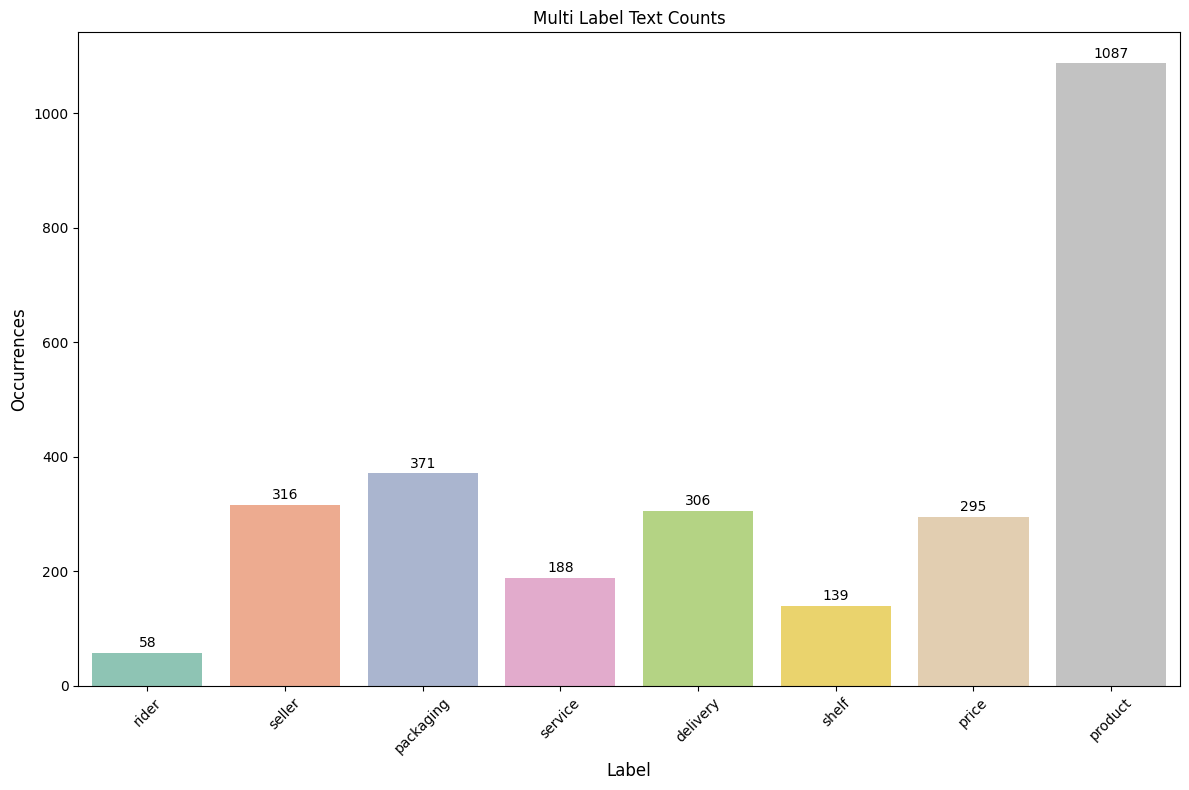

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sum values of label columns
x = df.iloc[:, 1:].sum()

# Choose an 8-color palette (Set2 has 8 colors)
palette = sns.color_palette("Set2", 8)

# Plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=x.index, y=x.values, palette=palette, alpha=0.8)

# Add labels and title
plt.title("Multi Label Text Counts")
plt.ylabel('Occurrences', fontsize=12)
plt.xlabel('Label', fontsize=12)

# Add value labels on top of bars
for rect, label in zip(ax.patches, x.values):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 5,
            int(label), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
df.reviewContent[2]

'আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে নিতে পারেন যে রকম কথা ছিল সেই রকম দিসে ধ্যনবাদ দারাজ এবং সেলার '

In [19]:
from sklearn.model_selection import train_test_split
# split into train and test
df_train, df_test = train_test_split(df, random_state=42, test_size=0.30, shuffle=True)
# split test into test and validation datasets
df_valid, df_test = train_test_split(df_test, random_state=42, test_size=0.33, shuffle=True)

In [20]:
print(f"Train: {df_train.shape}, Test: {df_test.shape}, Valid: {df_valid.shape}")

Train: (1106, 9), Test: (157, 9), Valid: (318, 9)


In [21]:
# Hyperparameters
MAX_LEN = 256
TRAIN_BATCH_SIZE = 32
VALID_BATCH_SIZE = 32
TEST_BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-05
THRESHOLD = 0.5 # threshold for the sigmoid


In [22]:
from transformers import BertTokenizer, BertModel

import os
import pandas as pd
import numpy as np
import shutil
import sys
import tqdm.notebook as tq
from collections import defaultdict

import torch
import torch.nn as nn

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

2025-05-13 04:55:59.056852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747112159.508105      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747112159.644212      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [23]:
# tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [24]:
# Test the tokenizer
test_text = "আলহামদুলিল্লাহ, প্রোডাক্টটি অনেক ভালো! সাউন্ড চেক করে দেখলাম অনেক ভালই! আপনার চোখ বন্ধ করে ভরসা করে নিতে পারেন! প্রোডাক্টটি যখন আমার হাতে এসেছিল তখন ইনটেক ছিল!"
# generate encodings
encodings = tokenizer.encode_plus(test_text,
                                  add_special_tokens = True,
                                  max_length = 50,
                                  truncation = True,
                                  padding = "max_length",
                                  return_attention_mask = True,
                                  return_tensors = "pt")
# we get a dictionary with three keys (see: https://huggingface.co/transformers/glossary.html)
encodings


{'input_ids': tensor([[  101,  1348, 29909, 29913, 29914, 29906, 29900, 29909, 29915, 29909,
         29909, 29914, 29913,  1010,  1367, 29908, 29917, 29914, 29896, 29914,
         29889, 29895, 29895, 29915,  1347, 29902, 29917, 29889,  1369, 29914,
         29909, 29917, 29914,   999,  1376, 29914, 29886, 29902, 29896,  1356,
         29917, 29889,  1353, 29908, 29917,  1364, 29917, 29890, 29909,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1]])}

In [25]:
df_train['reviewContent']

1106                          মেরিল সাবান ডেলিভারি হয়েছে
591                               উপহারের জন্য ধন্যবাদ ️️
680     ভালো প্রোডাক্ট ধন্যবাদ দারাজ প্রোডাক্টটি সুপার...
1128    ব্লেন্ড এবং সুবাস ভালো নয় যারা ক্লাসিক জারের ...
1218       প্যাকেজিং ভালো ছিলো না টিন বক্স বাঁকা হয়ে গেছে
                              ...                        
1158    অনেক ভালো একটি পণ্য সবাই নিতে পারেন বাজারে এর ...
1333                                   ঠিকমতো মোড়ানো হয়নি
862                    কম দামে অরিজিনাল প্রোডাক্ট পেয়েছি
1515       ঠিক মতো পেয়েছি দূরে আছি তাই ছবি দিতে পারলামনা 
1154    পণ্যটি যথাযথভাবে পাঠানোর জন্য সেলারকে ধন্যবাদ ...
Name: reviewContent, Length: 1106, dtype: object

In [26]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len, target_list):
        self.tokenizer = tokenizer
        self.df = df
        self.title = list(df['reviewContent'])
        self.targets = self.df[target_list].values
        self.max_len = max_len

    def __len__(self):
        return len(self.title)

    def __getitem__(self, index):
        title = str(self.title[index])
        title = " ".join(title.split())
        inputs = self.tokenizer.encode_plus(
            title,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=True,
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs["token_type_ids"].flatten(),
            'targets': torch.FloatTensor(self.targets[index]),
            'title': title
        }


In [27]:
target_list = list(df.columns)
target_list

['reviewContent',
 'rider',
 'seller',
 'packaging',
 'service',
 'delivery',
 'shelf',
 'price',
 'product']

In [28]:
target_list = target_list[1:]

In [29]:
target_list

['rider',
 'seller',
 'packaging',
 'service',
 'delivery',
 'shelf',
 'price',
 'product']

In [30]:
train_dataset = CustomDataset(df_train, tokenizer, MAX_LEN, target_list)
valid_dataset = CustomDataset(df_valid, tokenizer, MAX_LEN, target_list)
test_dataset = CustomDataset(df_test, tokenizer, MAX_LEN, target_list)

In [31]:
# testing the dataset
next(iter(train_dataset))

{'input_ids': tensor([  101,  1370, 29917, 29908, 29915, 29909,  1376, 29914, 29904, 29914,
         29902,  1360, 29917, 29909, 29915, 29905, 29914, 29908, 29915,  1377,
         29907, 29917, 29893, 29917,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [32]:
# Data loaders
train_data_loader = torch.utils.data.DataLoader(train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_data_loader = torch.utils.data.DataLoader(valid_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_data_loader = torch.utils.data.DataLoader(test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [33]:
class BERTClass(torch.nn.Module):
    def __init__(self):
        super(BERTClass, self).__init__()
        self.bert_model = BertModel.from_pretrained('bert-base-uncased', return_dict=True)
        self.dropout = torch.nn.Dropout(0.3)
        self.linear = torch.nn.Linear(768, 8)

    def forward(self, input_ids, attn_mask, token_type_ids):
        output = self.bert_model(
            input_ids,
            attention_mask=attn_mask,
            token_type_ids=token_type_ids
        )
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)
        return output

model = BERTClass()

# Freezing BERT layers: (tested, weaker convergence)
# for param in model.bert_model.parameters():
#     param.requires_grad = False

model.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERTClass(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [34]:
# BCEWithLogitsLoss combines a Sigmoid layer and the BCELoss in one single class.
# This version is more numerically stable than using a plain Sigmoid followed
# by a BCELoss as, by combining the operations into one layer,
# we take advantage of the log-sum-exp trick for numerical stability.
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [35]:
from torch.optim import AdamW # Importing AdamW from torch.optim

# define the optimizer
optimizer = AdamW(model.parameters(), lr = 1e-5)

In [36]:
# Training of the model for one epoch
def train_model(training_loader, model, optimizer):

    losses = []
    correct_predictions = 0
    num_samples = 0
    # set model to training mode (activate droput, batch norm)
    model.train()
    # initialize the progress bar
    loop = tq.tqdm(enumerate(training_loader), total=len(training_loader),
                      leave=True, colour='steelblue')
    for batch_idx, data in loop:
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        # forward
        outputs = model(ids, mask, token_type_ids) # (batch,predict)=(32,8)
        loss = loss_fn(outputs, targets)
        losses.append(loss.item())
        # training accuracy, apply sigmoid, round (apply thresh 0.5)
        outputs = torch.sigmoid(outputs).cpu().detach().numpy().round()
        targets = targets.cpu().detach().numpy()
        correct_predictions += np.sum(outputs==targets)
        num_samples += targets.size   # total number of elements in the 2D array

        # backward
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # grad descent step
        optimizer.step()

        # Update progress bar
        #loop.set_description(f"")
        #loop.set_postfix(batch_loss=loss)

    # returning: trained model, model accuracy, mean loss
    return model, float(correct_predictions)/num_samples, np.mean(losses)

In [37]:
def eval_model(validation_loader, model, optimizer):
    losses = []
    correct_predictions = 0
    num_samples = 0
    # set model to eval mode (turn off dropout, fix batch norm)
    model.eval()

    with torch.no_grad():
        for batch_idx, data in enumerate(validation_loader, 0):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model(ids, mask, token_type_ids)

            loss = loss_fn(outputs, targets)
            losses.append(loss.item())

            # validation accuracy
            # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs).cpu().detach().numpy().round()
            targets = targets.cpu().detach().numpy()
            correct_predictions += np.sum(outputs==targets)
            num_samples += targets.size   # total number of elements in the 2D array

    return float(correct_predictions)/num_samples, np.mean(losses)

**Model Training**

In [38]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(1, EPOCHS+1):
    print(f'Epoch {epoch}/{EPOCHS}')
    model, train_acc, train_loss = train_model(train_data_loader, model, optimizer)
    val_acc, val_loss = eval_model(val_data_loader, model, optimizer)

    print(f'train_loss={train_loss:.4f}, val_loss={val_loss:.4f} train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    # save the best model
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), "MLTC_model_state.bin")
        best_accuracy = val_acc

# https://github.com/dtolk/multilabel-BERT/blob/master/notebooks/multi_label_text_classification_BERT.ipynb

Epoch 1/50


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.5578, val_loss=0.4549 train_acc=0.7456, val_acc=0.8282
Epoch 2/50


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.4435, val_loss=0.4242 train_acc=0.8310, val_acc=0.8294
Epoch 3/50


...

train_loss=0.0362, val_loss=0.2098 train_acc=0.9977, val_acc=0.9332
Epoch 49/50


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.0343, val_loss=0.2091 train_acc=0.9986, val_acc=0.9347
Epoch 50/50


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.0336, val_loss=0.2133 train_acc=0.9981, val_acc=0.9336


In [39]:
import matplotlib.pyplot as plt

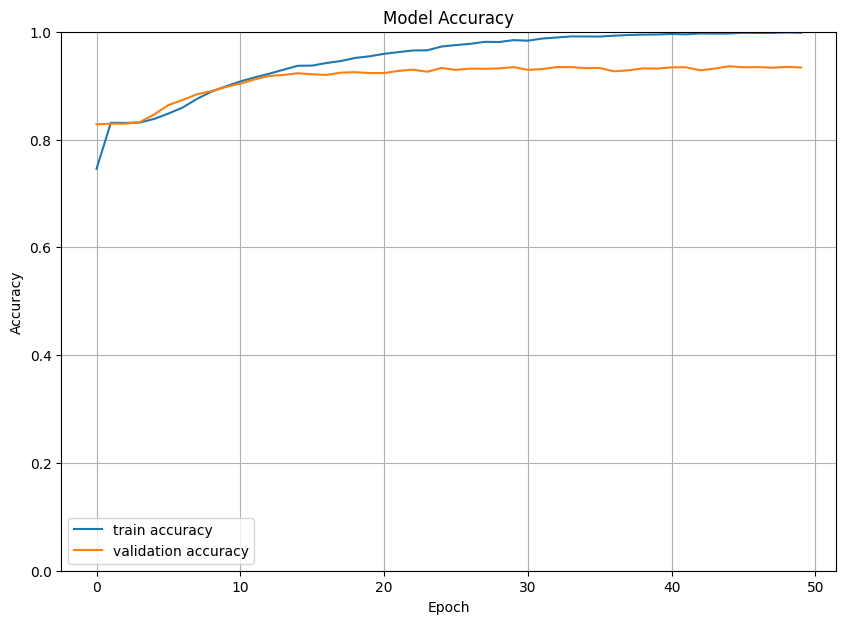

In [40]:
plt.rcParams["figure.figsize"] = (10,7)
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);
plt.grid()

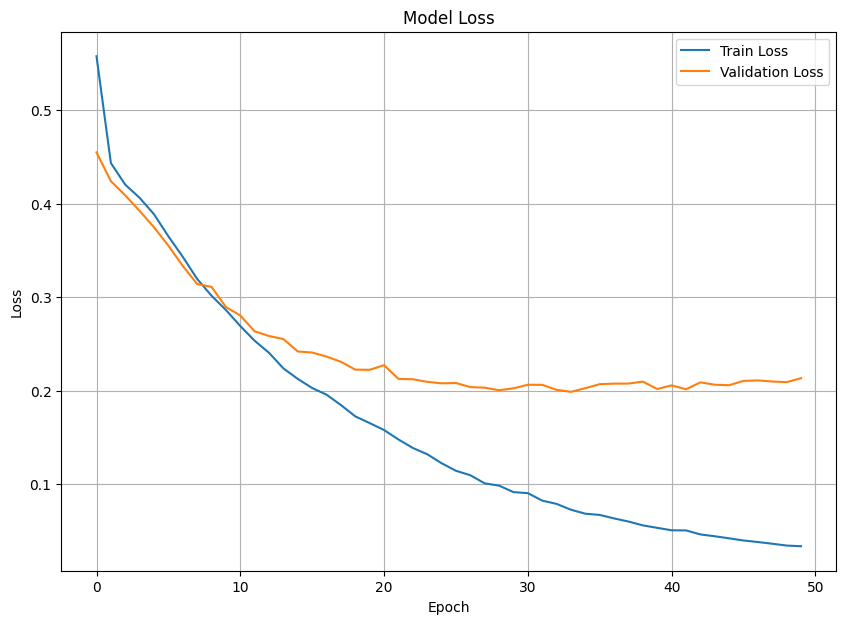

In [41]:
# Plot Loss
plt.rcParams["figure.figsize"] = (10,7)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

**Evaluation of the model**

In [42]:
# Loading pretrained model (best model)
model = BERTClass()
model.load_state_dict(torch.load("/kaggle/working/MLTC_model_state.bin"))
model = model.to(device)


/tmp/ipykernel_19/3981612500.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/MLTC_model_state.bin"))


In [43]:
# Evaluate the model using the test data
test_acc, test_loss = eval_model(test_data_loader, model, optimizer)

In [44]:
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9299, Test Loss: 0.2069


In [45]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

In [46]:
def get_predictions(model, data_loader):
    """
    Outputs:
      predictions -
    """
    model = model.eval()

    titles = []
    predictions = []
    prediction_probs = []
    target_values = []

    with torch.no_grad():
        for data in data_loader:
            title = data["title"]
            ids = data["input_ids"].to(device, dtype = torch.long)
            mask = data["attention_mask"].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data["targets"].to(device, dtype = torch.float)

            outputs = model(ids, mask, token_type_ids)
            # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs).detach().cpu()
            # thresholding at 0.5
            preds = outputs.round()
            targets = targets.detach().cpu()

            titles.extend(title)
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            target_values.extend(targets)

    predictions = torch.stack(predictions)
    prediction_probs = torch.stack(prediction_probs)
    target_values = torch.stack(target_values)

    return titles, predictions, prediction_probs, target_values

In [47]:
titles, predictions, prediction_probs, target_values = get_predictions(model, test_data_loader)

In [48]:
# sanity check
predictions.numpy()

array([[0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 1.]], dtype=float32)

In [49]:
print(f"titles:{len(titles)} \npredictions:{predictions.shape} \nprediction_probs:{prediction_probs.shape} \ntarget_values:{target_values.shape}")

titles:157 
predictions:torch.Size([157, 8]) 
prediction_probs:torch.Size([157, 8]) 
target_values:torch.Size([157, 8])


In [50]:
# Generate Classification Metrics
#
# note that the total support is greater than the number of samples
# some samples have multiple lables

print(classification_report(target_values, predictions, target_names=target_list))

              precision    recall  f1-score   support

       rider       1.00      0.75      0.86         8
      seller       0.85      0.94      0.89        35
   packaging       0.90      0.92      0.91        38
     service       0.64      0.32      0.42        22
    delivery       0.78      0.83      0.81        30
       shelf       1.00      0.82      0.90        17
       price       0.90      0.90      0.90        30
     product       0.81      0.89      0.85        98

   micro avg       0.84      0.84      0.84       278
   macro avg       0.86      0.80      0.82       278
weighted avg       0.84      0.84      0.83       278
 samples avg       0.85      0.86      0.84       278



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [51]:
target_values

tensor([[0., 1., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        ...,
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 1., 0., 1.]])

In [52]:
print('Accuracy = ', accuracy_score(target_values,predictions))
print('F1 score is ',f1_score(target_values, predictions, average="micro"))
print('Hamming Loss is ', hamming_loss(target_values, predictions))

Accuracy =  0.6369426751592356
F1 score is  0.841726618705036
Hamming Loss is  0.07006369426751592


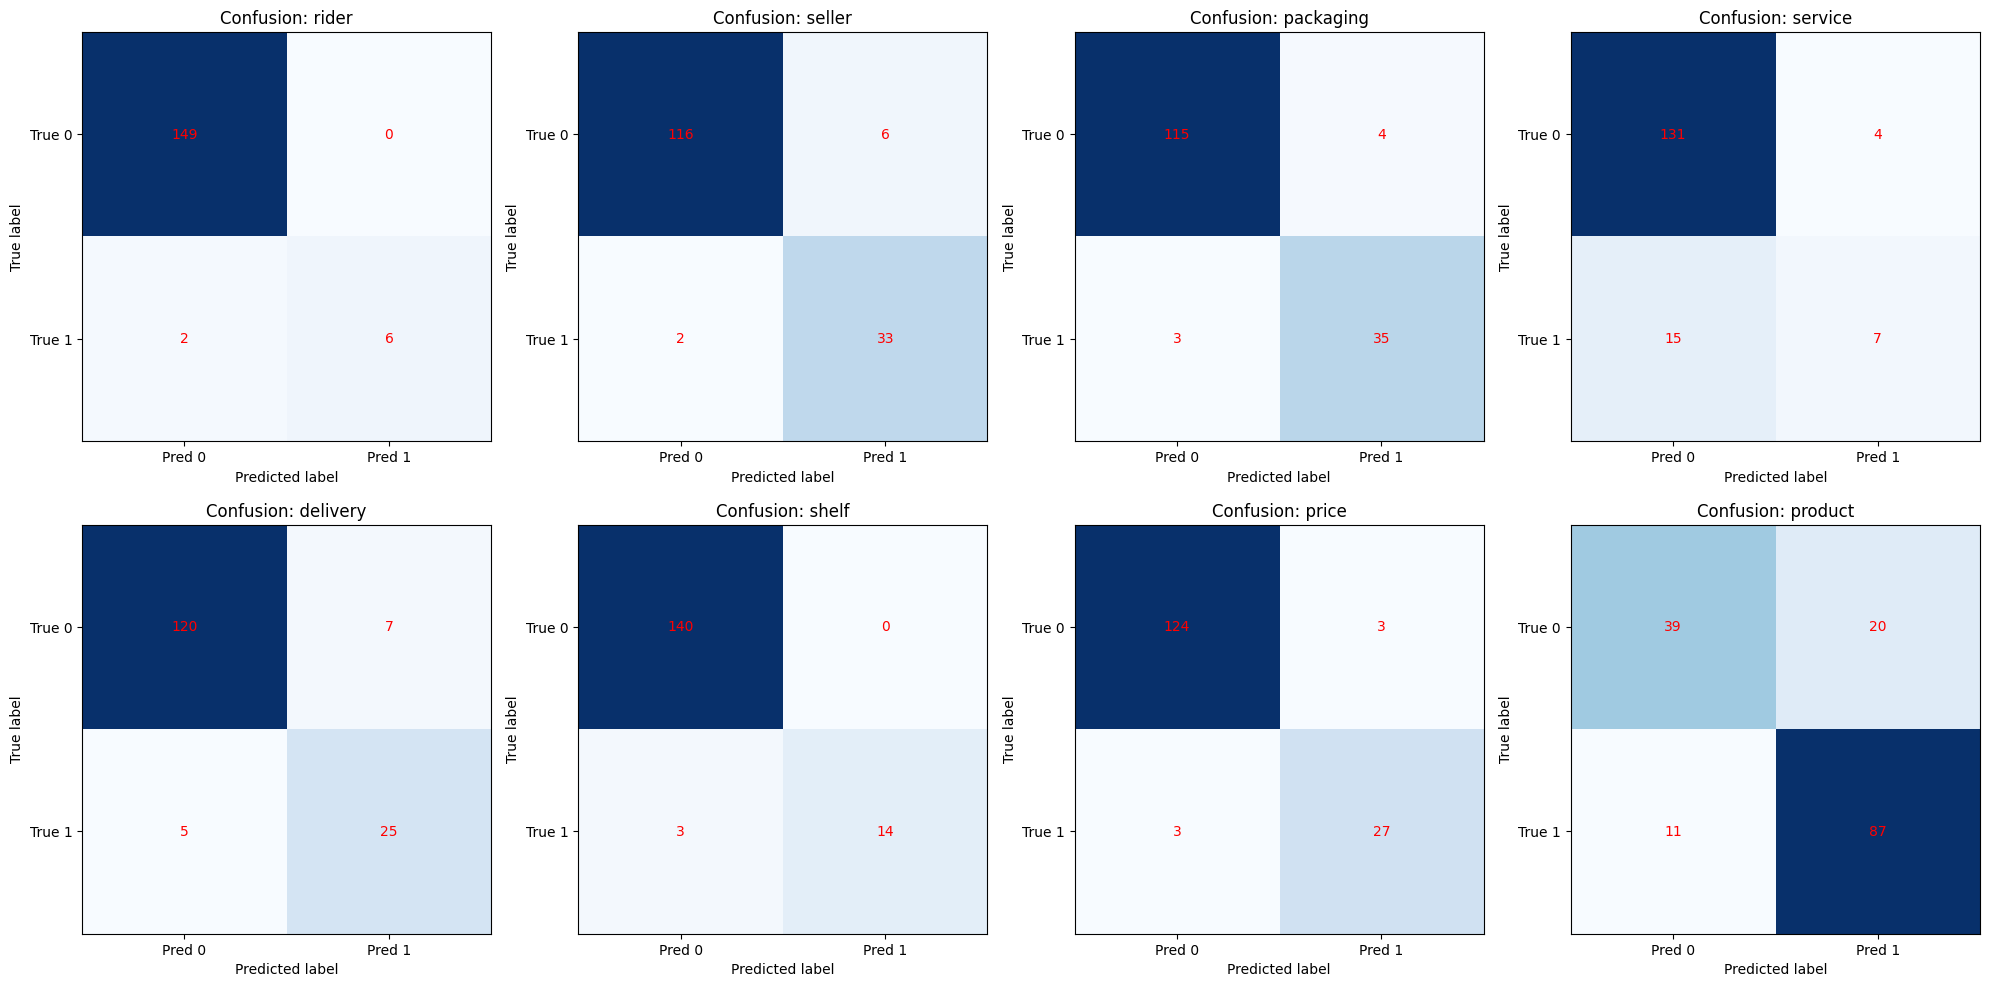

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, classification_report
# Compute multi-label confusion matrices
mcm = multilabel_confusion_matrix(target_values, predictions)

# Plot all 8 confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i in range(8):
    cm = mcm[i]
    ax = axes[i]
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Confusion: {target_list[i]}')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])

    for j in range(2):
        for k in range(2):
            ax.text(k, j, cm[j, k], ha='center', va='center', color='red')

    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()


# > **Inference**

In [54]:
# raw text
raw_text = """
১০০% আসল প্রোডাক্ট। সিলেটের মধ্যে ৮ দিনের মধ্যে ডেলিভারি হয়েছে। বিক্রেতা খুবই সহানুভূতিশীল এবং ভালো ছিলেন। এই প্রোডাক্টটি এই বিক্রেতার কাছ থেকে কেনার জন্য অত্যন্ত সুপারিশ করছি।
"""

In [55]:
encoded_text = tokenizer.encode_plus(
    raw_text,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_token_type_ids=True,
    pad_to_max_length=True,
    return_attention_mask=True,
    return_tensors='pt',
)

input_ids = encoded_text['input_ids'].to(device)
attention_mask = encoded_text['attention_mask'].to(device)
token_type_ids = encoded_text['token_type_ids'].to(device)
output = model(input_ids, attention_mask, token_type_ids)
 # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
output = torch.sigmoid(output).detach().cpu()
# thresholding at 0.5
output = output.flatten().round().numpy()
output

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


array([0., 1., 0., 0., 1., 0., 0., 1.], dtype=float32)

In [56]:
# Correctly identified the topic of the paper: High energy physics
print(f"Title: {raw_text}")
for idx, p in enumerate(output):
    if p==1:
        print(f"Label: {target_list[idx]}")

Title: 
১০০% আসল প্রোডাক্ট। সিলেটের মধ্যে ৮ দিনের মধ্যে ডেলিভারি হয়েছে। বিক্রেতা খুবই সহানুভূতিশীল এবং ভালো ছিলেন। এই প্রোডাক্টটি এই বিক্রেতার কাছ থেকে কেনার জন্য অত্যন্ত সুপারিশ করছি।

Label: seller
Label: delivery
Label: product


In [57]:
titles, predictions, prediction_probs, target_values = get_predictions(model, test_data_loader)

# Convert tensors to numpy arrays
predictions_np = predictions.numpy()
target_values_np = target_values.numpy()

# Subset accuracy (exact match)
exact_match_accuracy = accuracy_score(target_values_np, predictions_np)

# F1 score (micro and macro)
f1_micro = f1_score(target_values_np, predictions_np, average='micro')

# Hamming loss
hamming = hamming_loss(target_values_np, predictions_np)

# Print results
print(f"Exact Match Accuracy: {exact_match_accuracy:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")
print(f"Hamming Loss: {hamming:.4f}")


Exact Match Accuracy: 0.6369
F1 Score (Micro): 0.8417
Hamming Loss: 0.0701
